# Imports

In [ ]:
import pandas as pd

import random
import numpy as np
import joblib

import matplotlib.pyplot as plt
import seaborn as sns
import json

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import time
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,precision_recall_fscore_support,)

from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt

# Data Loading

In [ ]:
with open('../data/processed/feature_names.json', 'r') as f:
    feature_names = json.load(f)

df_microbes = pd.read_csv(r"C:\Users\Usuario\Proyectos\Practica\microbes\Data\raw\microbes.csv")
x_train = pd.DataFrame(np.load('../data/processed/X_train.npy'), columns=feature_names)
x_test = pd.DataFrame(np.load('../data/processed/X_test.npy'), columns=feature_names)
y_train = np.load('../data/processed/y_train.npy', allow_pickle=True)
y_test = np.load('../data/processed/y_test.npy', allow_pickle=True)

# Evaluation Metrics

Given the multiclass nature of this problem, and the imbalance between classes, the following metrics were selected: 

**F1 Score:** As it penalizes both false positives and false negatives, important for smaller classes.

**Macro avg F1-Score:** Each class contributes equally regardless of its sample size, making it the most honest metric under class imbalance.

**Weighted avg F1-Score:** the mean of F1 weighted by the number of samples per class, reflecting overall model performance on the dataset.

# Predictive Modeling

## Random Forest

--- Random Forest Results ---
                precision    recall  f1-score   support

Aspergillus sp       0.97      0.81      0.88       778
        Diatom       0.57      0.99      0.72       364
    Penicillum       0.99      1.00      1.00       216
    Pithophora       0.91      0.82      0.86       270
      Protozoa       0.97      0.99      0.98       778
      Raizopus       1.00      1.00      1.00       510
     Spirogyra       0.98      0.77      0.86       122
      Ulothrix       0.96      0.85      0.90      1484
        Volvox       0.85      0.92      0.88       864
         Yeast       0.94      0.93      0.93       720

      accuracy                           0.91      6106
     macro avg       0.91      0.91      0.90      6106
  weighted avg       0.92      0.91      0.91      6106

Training time: 4.478 s


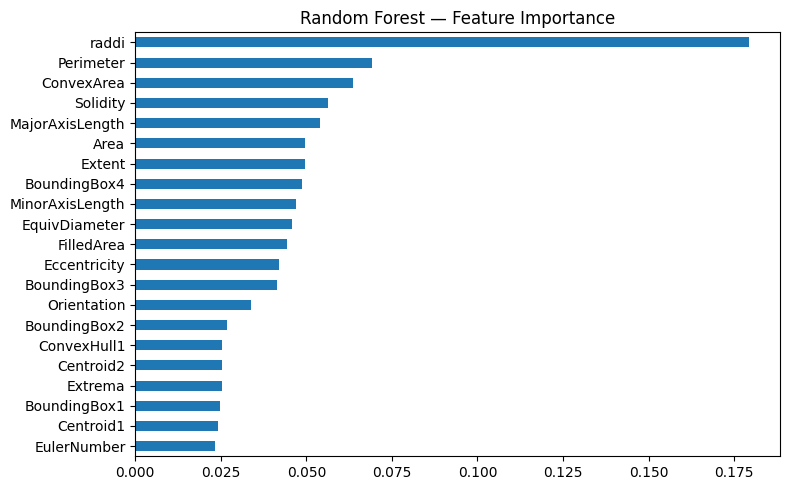

In [18]:
# Initialize and train


rf_model = RandomForestClassifier(n_estimators=140, class_weight='balanced', max_depth= 12, random_state=42)
t0 = time.perf_counter()
rf_model.fit(x_train, y_train)
training_time_rf = time.perf_counter() - t0

# Predictions
y_pred_rf = rf_model.predict(x_test)

# Metrics
precision_rf, recall_rf, f1_rf, _ = precision_recall_fscore_support(
    y_test, y_pred_rf, average="weighted"
)

# Evaluation
print("--- Random Forest Results ---")
print(classification_report(y_test, y_pred_rf))
print(f"Training time: {training_time_rf:.3f} s")

# Feature importance
importance = pd.Series(rf_model.feature_importances_, index=x_train.columns).sort_values(ascending=True)
importance.plot(kind="barh", figsize=(8, 5), title="Random Forest — Feature Importance")
plt.tight_layout()
plt.show()

## Random Forest (GridSearch)

--- Random Forest (GridSearchCV) Results ---
Best params: {'max_depth': 15, 'min_samples_leaf': 1, 'n_estimators': 150}
                precision    recall  f1-score   support

Aspergillus sp       0.98      0.95      0.97       778
        Diatom       0.84      1.00      0.91       364
    Penicillum       1.00      1.00      1.00       216
    Pithophora       0.99      0.93      0.96       270
      Protozoa       1.00      1.00      1.00       778
      Raizopus       1.00      1.00      1.00       510
     Spirogyra       1.00      0.79      0.88       122
      Ulothrix       0.99      0.97      0.98      1484
        Volvox       0.98      0.99      0.99       864
         Yeast       0.98      0.99      0.99       720

      accuracy                           0.98      6106
     macro avg       0.98      0.96      0.97      6106
  weighted avg       0.98      0.98      0.98      6106

Training time: 45.864 s


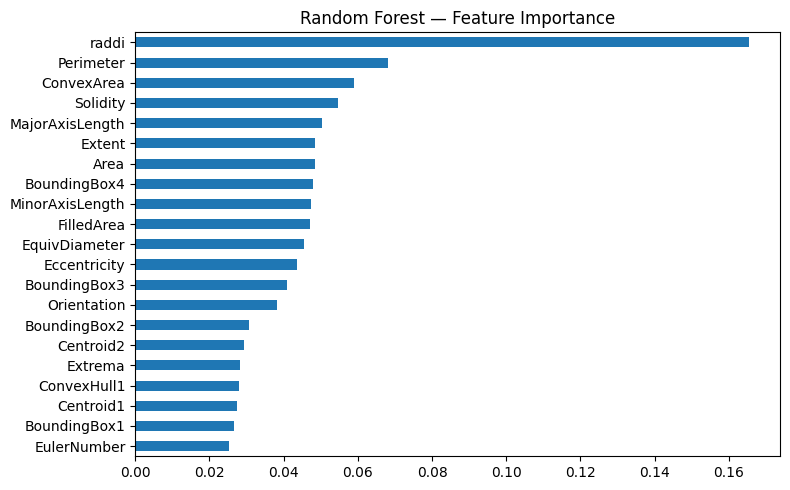

In [15]:
param_grid_rf = {
    "n_estimators": [100, 150, 200],          
    "max_depth": [12, 15],           
    "min_samples_leaf": [1, 2],         
}
gs_rf = GridSearchCV(
    estimator=RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid=param_grid_rf,
    cv=5,
    scoring="recall_macro",
    n_jobs=-1,
)
t0 = time.perf_counter()
gs_rf.fit(x_train, y_train)
training_time_rf = time.perf_counter() - t0
rfgs_model = gs_rf.best_estimator_

# Predictions
y_pred_gsrf = rfgs_model.predict(x_test)

# Metrics
precision_rf, recall_rf, f1_rf, _ = precision_recall_fscore_support(
    y_test, y_pred_gsrf, average="weighted"
)

# Evaluation
print("--- Random Forest (GridSearchCV) Results ---")
print("Best params:", gs_rf.best_params_)
print(classification_report(y_test, y_pred_gsrf))
print(f"Training time: {training_time_rf:.3f} s")

# Feature importance
importance = pd.Series(rfgs_model.feature_importances_, index=x_train.columns).sort_values(ascending=True)
importance.plot(kind="barh", figsize=(8, 5), title="Random Forest — Feature Importance")
plt.tight_layout()
plt.show()

## XGBoost

                precision    recall  f1-score   support

Aspergillus sp       0.97      0.94      0.95       778
        Diatom       0.94      1.00      0.97       364
    Penicillum       1.00      1.00      1.00       216
    Pithophora       0.98      0.90      0.94       270
      Protozoa       0.99      1.00      1.00       778
      Raizopus       1.00      1.00      1.00       510
     Spirogyra       1.00      0.79      0.88       122
      Ulothrix       0.96      0.98      0.97      1484
        Volvox       0.97      0.99      0.98       864
         Yeast       0.98      0.98      0.98       720

      accuracy                           0.97      6106
     macro avg       0.98      0.96      0.97      6106
  weighted avg       0.97      0.97      0.97      6106



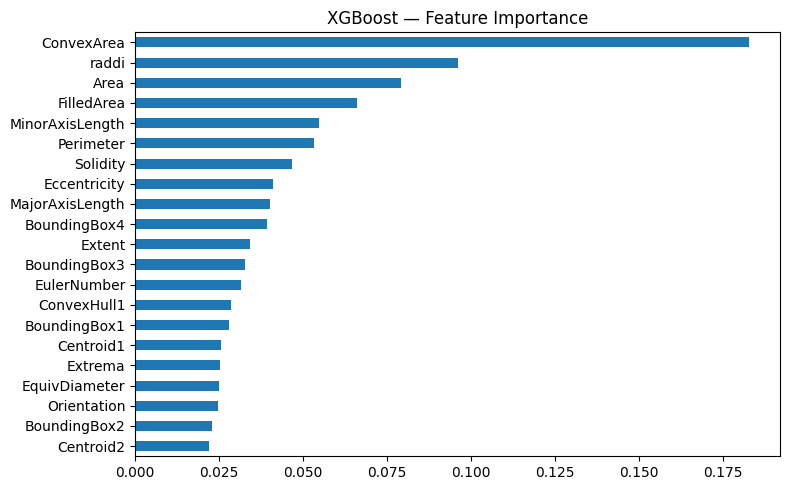

In [ ]:
#Target numérico
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

xgb = XGBClassifier(
    n_estimators=100,
    eval_metric='mlogloss',
    learning_rate= 0.15,
    random_state=42,
    n_jobs=-1
)

xgb.fit(x_train, y_train_enc)
y_pred_xgb = xgb.predict(x_test)
print(classification_report(y_test_enc, y_pred_xgb, target_names=le.classes_))

importance = pd.Series(xgb.feature_importances_, index=x_train.columns).sort_values(ascending=True)
importance.plot(kind="barh", figsize=(8, 5), title="XGBoost — Feature Importance")
plt.tight_layout()
plt.show()

## XGBoost (GridSearch)

--- XGBoost (GridSearchCV) Results ---
Best params: {'learning_rate': 0.15, 'max_depth': 8, 'min_child_weight': 1, 'n_estimators': 140}
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       778
           1       0.99      1.00      0.99       364
           2       1.00      1.00      1.00       216
           3       0.98      0.97      0.98       270
           4       1.00      1.00      1.00       778
           5       1.00      1.00      1.00       510
           6       1.00      0.79      0.88       122
           7       0.99      0.99      0.99      1484
           8       0.99      1.00      1.00       864
           9       1.00      1.00      1.00       720

    accuracy                           0.99      6106
   macro avg       0.99      0.97      0.98      6106
weighted avg       0.99      0.99      0.99      6106

Training time: 162.950 s


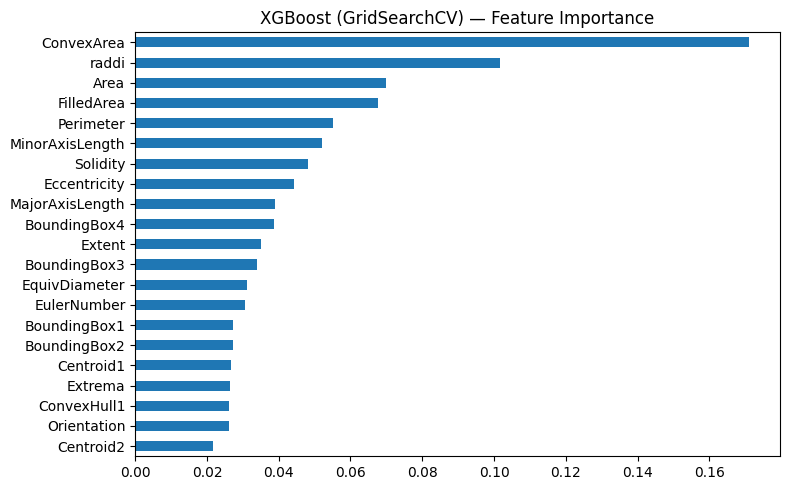

In [ ]:
param_grid_xgb = {
    "n_estimators": [100, 120, 140],       
    "max_depth": [6, 8],               
    "learning_rate": [0.1, 0.15],    
    "min_child_weight": [1, 3]          
}
base_xgb = XGBClassifier(random_state=42, eval_metric="mlogloss")
gs_xgb = GridSearchCV(
    estimator=base_xgb,
    param_grid=param_grid_xgb,
    cv=5,
    scoring="recall_macro",
    n_jobs=-1,
)
t0 = time.perf_counter()
gs_xgb.fit(x_train, y_train_enc)
training_time_xgb_gs = time.perf_counter() - t0
xgb_model_gs = gs_xgb.best_estimator_

y_pred_xgb_gs = xgb_model_gs.predict(x_test)
precision_xgb_gs, recall_xgb_gs, f1_xgb_gs, _ = precision_recall_fscore_support(
    y_test_enc, y_pred_xgb_gs, average="weighted"
)

print("--- XGBoost (GridSearchCV) Results ---")
print("Best params:", gs_xgb.best_params_)
print(classification_report(y_test_enc, y_pred_xgb_gs, target_names=le.classes_))
print(f"Training time: {training_time_xgb_gs:.3f} s")

importance_gs = pd.Series(xgb_model_gs.feature_importances_, index=x_train.columns).sort_values(ascending=True)
importance_gs.plot(kind="barh", figsize=(8, 5), title="XGBoost (GridSearchCV) — Feature Importance")
plt.tight_layout()
plt.show()

# Model Comparison

                          Accuracy  F1 Macro  F1 Weighted  Precision Weighted  \
Model                                                                           
Random Forest               0.9777    0.9670       0.9778              0.9795   
GridSearch Random Forest    0.9777    0.9670       0.9778              0.9795   
XGBoost                     0.9745    0.9669       0.9741              0.9748   
 GridSearch XGBoost         0.9916    0.9821       0.9914              0.9917   

                          Recall Weighted  
Model                                      
Random Forest                      0.9777  
GridSearch Random Forest           0.9777  
XGBoost                            0.9745  
 GridSearch XGBoost                0.9916  


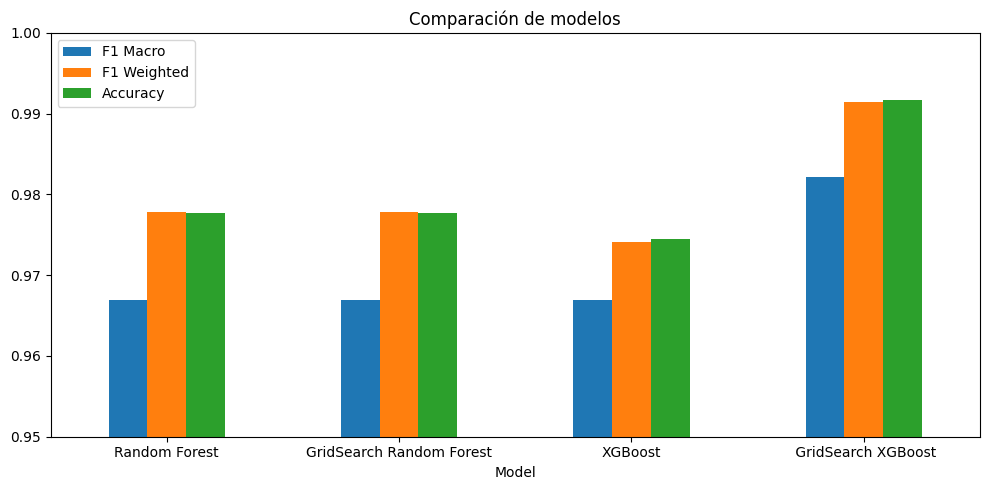

In [ ]:
# Extraer métricas resumen de cada modelo
def extract_metrics(y_true, y_pred, model_name):
    report = classification_report(y_true, y_pred, output_dict=True)
    return {
        'Model': model_name,
        'Accuracy': report['accuracy'],
        'F1 Macro': report['macro avg']['f1-score'],
        'F1 Weighted': report['weighted avg']['f1-score'],
        'Precision Weighted': report['weighted avg']['precision'],
        'Recall Weighted': report['weighted avg']['recall'],
    }

results = pd.DataFrame([
    extract_metrics(y_test, y_pred_rf, 'Random Forest'),
    extract_metrics(y_test, y_pred_rf, 'GridSearch Random Forest'), 
    extract_metrics(y_test_enc, y_pred_xgb, 'XGBoost'),  
    extract_metrics(y_test_enc, y_pred_xgb_gs, 'GridSearch XGBoost'),  
])

print(results.set_index('Model').round(4))

# Gráfico comparativo
results.set_index('Model')[['F1 Macro', 'F1 Weighted', 'Accuracy']].plot(
    kind='bar', figsize=(10, 5), ylim=(0.95, 1.0)
)
plt.title('Comparación de modelos')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The best performing model was **XGBoost with GridSearchCV** (best parameters: learning_rate=0.15, max_depth=8, min_child_weight=1, n_estimators=140), achieving an overall accuracy of 99% and a weighted F1-score of 0.99.

All classes reached an F1-score of 0.98 or above, with the exception of class 6 (Spirogyra), which obtained an F1-score of 0.88 due to its limited representation in the dataset (122 samples). This is consistent across all trained models and is attributed to class imbalance rather than a modeling limitation.

# Saving the best model

In [ ]:
joblib.dump(gs_xgb, '../models/xgboost_gridsearch.pkl')